In [1]:
import os 

cwd = os.getcwd()
sep = os.sep
cwd 

'/home/ugo/Scrivania/Transthyretin/docking'

In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import matplotlib.pyplot as plt
import numpy as np


def plot_2d_structures_from_sdfs(sdf_files, mols_per_row=3):
    molecules = []
    ligand_names = []
    for sdf_file in sdf_files:
        ligand_name = sdf_file.split(os.sep)[-1].replace(".sdf", "")
        ligand_name = ligand_name.replace("best_", "").replace("_preprocessed", "")
        #ligand_name = ligand_name.replace("_", " ").title()  # Format name for better readability
        if "optimized" in ligand_name:
            ligand_name = "tafamidis_optimised"
        elif ligand_name not in ["tafamidis", "acoramidis", "diflunisal", "tolcapone"]:
            ligand_name = "generated"
        ligand_names.append(ligand_name)
        suppl = Chem.SDMolSupplier(sdf_file)
        for mol in suppl:
            if mol is not None:
                AllChem.Compute2DCoords(mol)
                molecules.append(mol)
    
    n_mols = len(molecules)
    n_rows = (n_mols + mols_per_row - 1) // mols_per_row
    
    # Create subplots grid
    fig, axes = plt.subplots(n_rows, mols_per_row, figsize=(mols_per_row*4, n_rows*4))
    axes = axes.flatten() if n_mols > 1 else [axes]
    
    for i, (ax, mol) in enumerate(zip(axes, molecules)):
        img = Draw.MolToImage(mol, size=(800, 800))
        ax.imshow(np.array(img))
        ax.set_title(ligand_names[i], weight = "bold", fontsize = 16)  # Title for each subplot
        ax.axis('off')
    
    # Hide unused subplots
    for j in range(len(molecules), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    return fig 

Ligands found: ['/home/ugo/Scrivania/Transthyretin/docking/sdf-existing/diflunisal_preprocessed.sdf', '/home/ugo/Scrivania/Transthyretin/docking/sdf-existing/tolcapone_preprocessed.sdf', '/home/ugo/Scrivania/Transthyretin/docking/sdf-existing/tafamidis_preprocessed.sdf', '/home/ugo/Scrivania/Transthyretin/docking/sdf-existing/acoramidis_preprocessed.sdf', '/home/ugo/Scrivania/Transthyretin/docking/sdf-generated/best_y98f_T4_preprocessed.sdf', '/home/ugo/Scrivania/Transthyretin/docking/sdf-optimized/best_tafamidis_optimized_v142i_preprocessed.sdf']


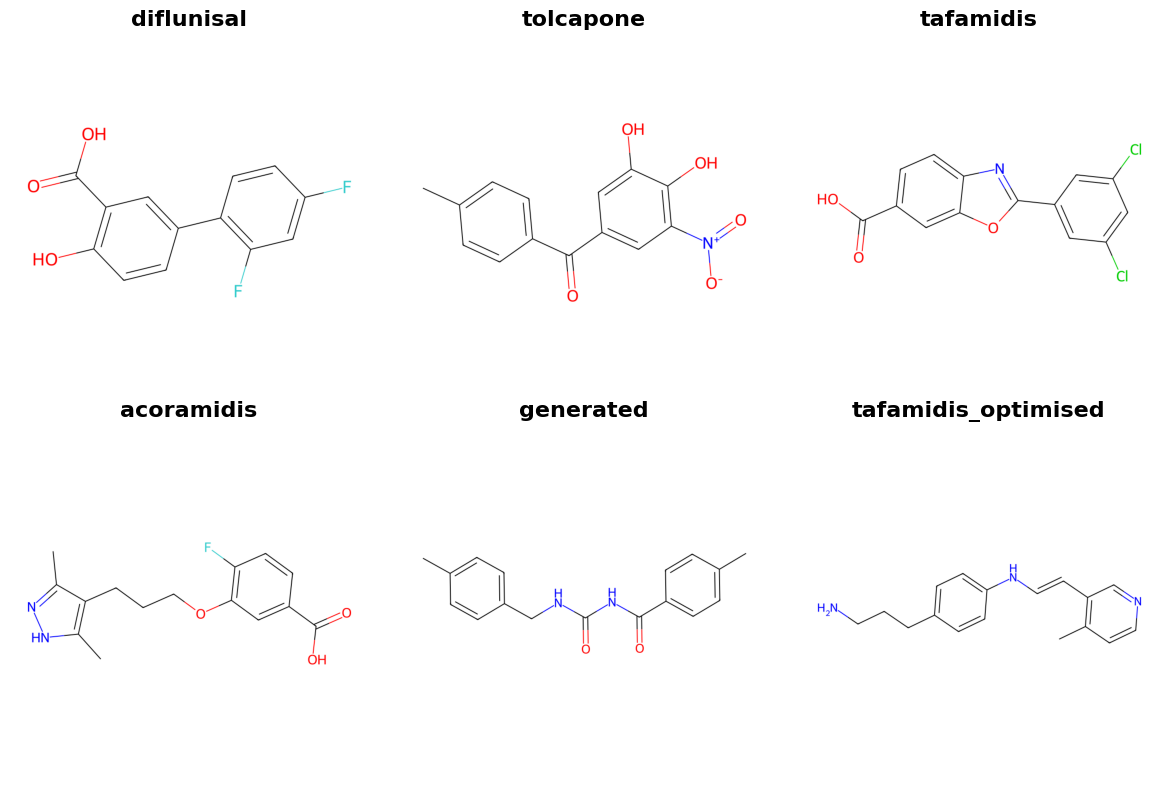

/tmp/ipykernel_11815/3046936838.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [7]:
sdf_types = ["existing", "generated", "optimized"]

ligands = []
for sdf_type in sdf_types:
    sdf_path = cwd + sep + f"sdf-{sdf_type}"
    ligands_files = [f for f in os.listdir(sdf_path) if f.endswith(".sdf")]
    ligands_files = [f for f in ligands_files if f.endswith("_preprocessed.sdf")]
    if sdf_type in ["generated", "optimized"]:
        ligands_files = [f for f in ligands_files if f.startswith("best_")]

    for ligand_file in ligands_files:
        ligands.append(sdf_path + sep + ligand_file)

print("Ligands found:", ligands)

fig = plot_2d_structures_from_sdfs(ligands)
fig.savefig(cwd + os.sep + "ligands_2d_structures.png", dpi=600, bbox_inches='tight')
fig.show()

In [8]:
fig.savefig(cwd + os.sep + "ligands_2d_structures.pdf", dpi=600, bbox_inches='tight')

In [12]:
import pandas as pd
df = pd.read_csv("ligand_descriptors.csv")
df["ligand"] = df["ligand"].apply(lambda x: x.replace("_preprocessed", "").replace("best_", "").replace(".sdf", ""))
df.sort_values(by="ligand", inplace=True)
df.drop(columns=["smile"], inplace=True, errors='ignore')
df

,ligand,chiral,n_chiral_atoms,is_specified,n_rings,n_aromatic_rings,n_aliphatic_rings,log_p,tpsa,bb_permeability,hba,hbd,mw,lipinski_rule_of_3,lipinski_rule_of_5,qed_score
4,acoramidis,False,0,False,2,2,0,2.8754,75.21,-0.946098,5,2.0,292.305483,True,True,0.802723
1,diflunisal,False,0,False,2,2,0,3.0356,57.53,-0.373715,3,2.0,250.197626,True,True,0.860782
3,tafamidis,False,0,False,3,3,0,4.4998,63.33,0.221006,3,1.0,308.116280,True,True,0.756793
0,tafamidis_optimized_v142i,False,0,False,2,2,0,4.1374,50.94,0.377247,3,2.0,267.368740,True,True,0.843421
2,tolcapone,False,0,False,2,2,0,3.0686,103.35,-1.625904,3,2.0,273.240840,True,True,0.387105
5,y98f_T4,False,0,False,2,2,0,3.7248,58.20,-0.036716,4,2.0,282.337020,True,True,0.909000


In [13]:
df.values[5, :]

array(['y98f_T4', False, 0, False, 2, 2, 0, 3.7248000000000023, 58.2,
       -0.0367156799999983, 4, 2.0, 282.33702, True, True,
       0.9090000637725216], dtype=object)